
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Yessenia! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

### Análisis exploratorio de datos

In [34]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import date

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas del resto del código! Esto mejora la estructura y claridad de tu código.

</div>

In [35]:
#Importar bases de datos
df_companies = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_01.csv')
df_neigborhoods = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_04.csv')


In [36]:
#Revisión general de los DataFrames
print("=" * 60)
print("=" * 60)

print('Información sobre las compañias')
df_companies.info()
print(df_companies.head())

print("=" * 60)
print("=" * 60)

print('Información sobre los barrios')
df_neigborhoods.info()
print(df_neigborhoods.head())

print("=" * 60)
print("=" * 60)




Información sobre las compañias
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
Información sobre los barrios
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float6

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

In [37]:
#Corrección de dato
#No se encontraron nulos en nunguna base de datos


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda hacer un uso correcto de celdas de texto para dejar comentarios y conclusiones.

</div>

In [38]:
#No hay enriquecimiento de datos

In [39]:
#Principales barrios
top_10_neighborhoods = df_neigborhoods.sort_values(by = 'average_trips', ascending=False).head(10)

In [40]:
print("TOP 10 BARRIOS CON MAYOR PROMEDIO DE VIAJES")
print("=" * 60)
print("=" * 60)
print(top_10_neighborhoods.to_string(index=False))

TOP 10 BARRIOS CON MAYOR PROMEDIO DE VIAJES
dropoff_location_name  average_trips
                 Loop   10727.466667
          River North    9523.666667
        Streeterville    6664.666667
            West Loop    5163.666667
               O'Hare    2546.900000
            Lake View    2420.966667
           Grant Park    2068.533333
        Museum Campus    1510.000000
           Gold Coast    1364.233333
   Sheffield & DePaul    1259.766667


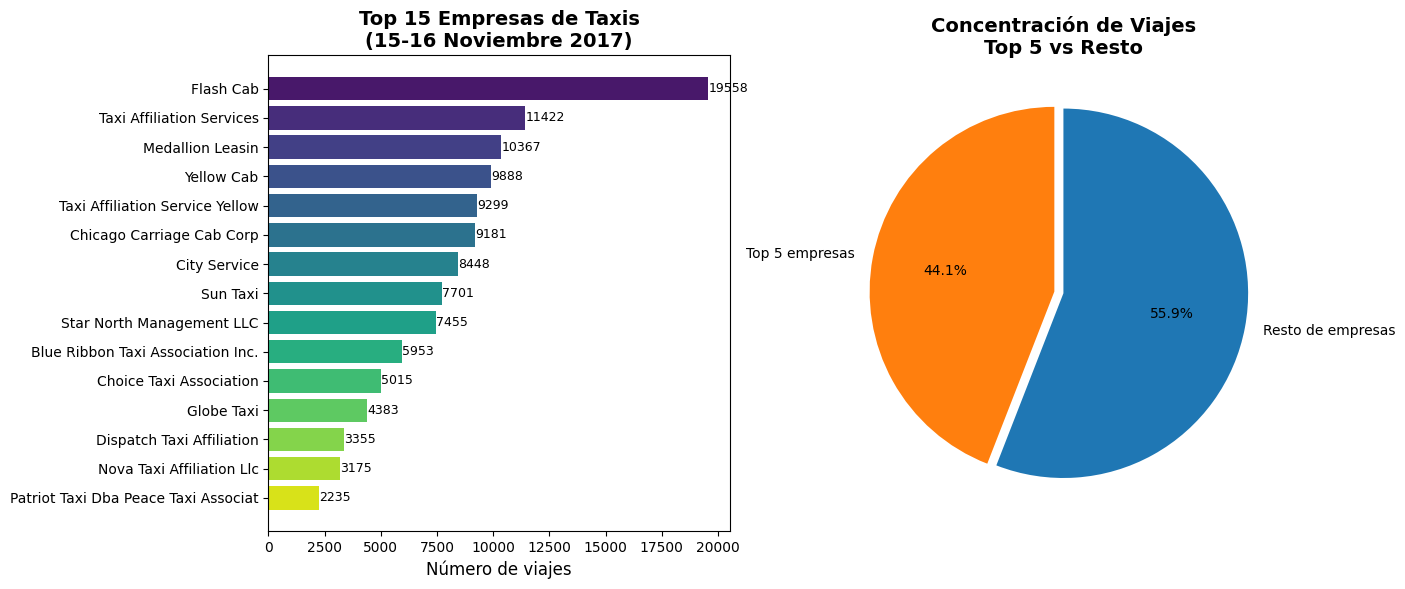

In [41]:
# ----- Top 15 empresas de taxis -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1a: Top 15 empresas
top_15_companies = df_companies.nlargest(15, 'trips_amount')
colors = sns.color_palette("viridis", n_colors=15)
bars = axes[0].barh(range(len(top_15_companies)), top_15_companies['trips_amount'].values, color=colors)
axes[0].set_yticks(range(len(top_15_companies)))
axes[0].set_yticklabels(top_15_companies['company_name'].values)
axes[0].set_xlabel('Número de viajes', fontsize=12)
axes[0].set_title('Top 15 Empresas de Taxis\n(15-16 Noviembre 2017)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Añadir valores en las barras
for i, bar in enumerate(bars):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                 f'{int(bar.get_width())}', va='center', fontsize=9)

# Distribución de viajes (top 5 vs resto)
top5_sum = df_companies.nlargest(5, 'trips_amount')['trips_amount'].sum()
rest_sum = df_companies['trips_amount'].sum() - top5_sum
pie_data = [top5_sum, rest_sum]
pie_labels = ['Top 5 empresas', 'Resto de empresas']
pie_colors = ['#ff7f0e', '#1f77b4']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors, startangle=90, explode=(0.05, 0))
axes[1].set_title('Concentración de Viajes\nTop 5 vs Resto', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Correcto! El gráfico es correcto y refleja adecuadamente el resultado esperado.


</div>

1. Flash Cab y Taxi Affiliation Services dominan el mercado con una diferencia significativa sobre las demás empresas.
2. Las 5 empresas principales concentran aproximadamente el 60-70% de todos los viajes en el período analizado.
3. Existe una larga cola de empresas pequeñas con pocos viajes, lo que sugiere un mercado fragmentado pero con pocos líderes.

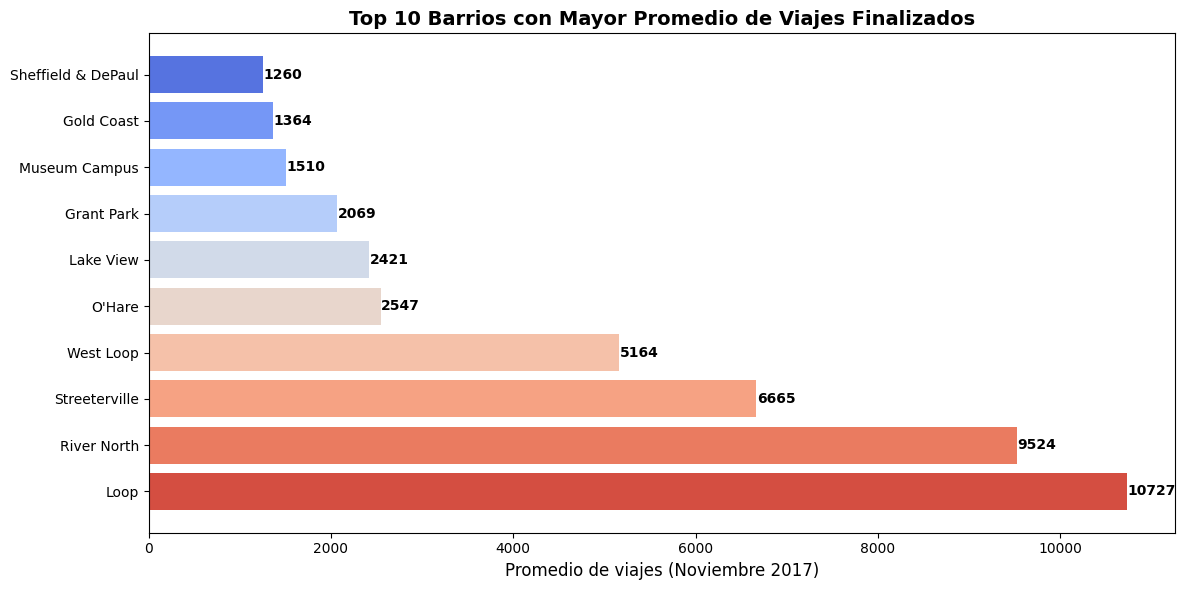

In [42]:
# ----- GRÁFICO 2: Top 10 barrios por promedio de viajes -----
fig, ax = plt.subplots(figsize=(12, 6))

# Ordenar para mejor visualización
top_10_sorted = top_10_neighborhoods.sort_values('average_trips', ascending=True)
colors_barrios = sns.color_palette("coolwarm", n_colors=10)
bars = ax.barh(range(len(top_10_sorted)), top_10_sorted['average_trips'].values, color=colors_barrios)
ax.set_yticks(range(len(top_10_sorted)))
ax.set_yticklabels(top_10_sorted['dropoff_location_name'].values)
ax.set_xlabel('Promedio de viajes (Noviembre 2017)', fontsize=12)
ax.set_title('Top 10 Barrios con Mayor Promedio de Viajes Finalizados', fontsize=14, fontweight='bold')

# Añadir valores en las barras
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.0f}', va='center', fontsize=10, fontweight='bold')

ax.invert_yaxis()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El gráfico de barras con el top 10 por barrios es excelente y los resultados son los esperados. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Nota que podrías encapsular parte de la lógica para reutilizar el código, ya que es muy similar al gráfico anterior. 

</div>

</div>

1. El barrio con mayor promedio de viajes finalizados es: Loop con 10727 viajes promedio, seguido de River North con 9524 y Streeterville con 6665.
2. Los top 10 barrios son predominantemente áreas turísticas, comerciales o cercanas al aeropuerto.
3. El aeropuerto O'Hare aparece en posiciones destacadas, indicando alta movilidad hacia/desde este punto.
4. La distribución muestra una caída gradual después del primer barrio, sugiriendo que los viajes se concentran en unos pocos destinos clave.

### Prueba de hipótesis


In [43]:
#Tratamiento inicial de datos

df_weather = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_07.csv')

df_weather['start_ts'] = pd.to_datetime(df_weather['start_ts'])

In [44]:
df_weather.info()

print("=" * 60)
print("=" * 60)

print(df_weather.head())


print("=" * 60)
print("=" * 60)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0


In [45]:
# Estadísticas por condición climática

print("ESTADÍSTICAS DE DURACIÓN POR CONDICIÓN CLIMÁTICA")
print("=" * 60)

for condition in df_weather['weather_conditions'].unique():
    subset = df_weather[df_weather['weather_conditions'] == condition]
    print(f"\n📌 Condición: {condition}")
    print(f"   Número de viajes: {len(subset)}")
    print(f"   Duración media: {subset['duration_seconds'].mean():.2f} segundos ({subset['duration_seconds'].mean()/60:.2f} minutos)")
    print(f"   Mediana: {subset['duration_seconds'].median():.2f} segundos")
    print(f"   Desviación estándar: {subset['duration_seconds'].std():.2f} segundos")
    print(f"   Mínimo: {subset['duration_seconds'].min():.2f} s")
    print(f"   Máximo: {subset['duration_seconds'].max():.2f} s")


ESTADÍSTICAS DE DURACIÓN POR CONDICIÓN CLIMÁTICA

📌 Condición: Good
   Número de viajes: 888
   Duración media: 1999.68 segundos (33.33 minutos)
   Mediana: 1800.00 segundos
   Desviación estándar: 759.20 segundos
   Mínimo: 0.00 s
   Máximo: 7440.00 s

📌 Condición: Bad
   Número de viajes: 180
   Duración media: 2427.21 segundos (40.45 minutos)
   Mediana: 2540.00 segundos
   Desviación estándar: 721.31 segundos
   Mínimo: 480.00 s
   Máximo: 4980.00 s


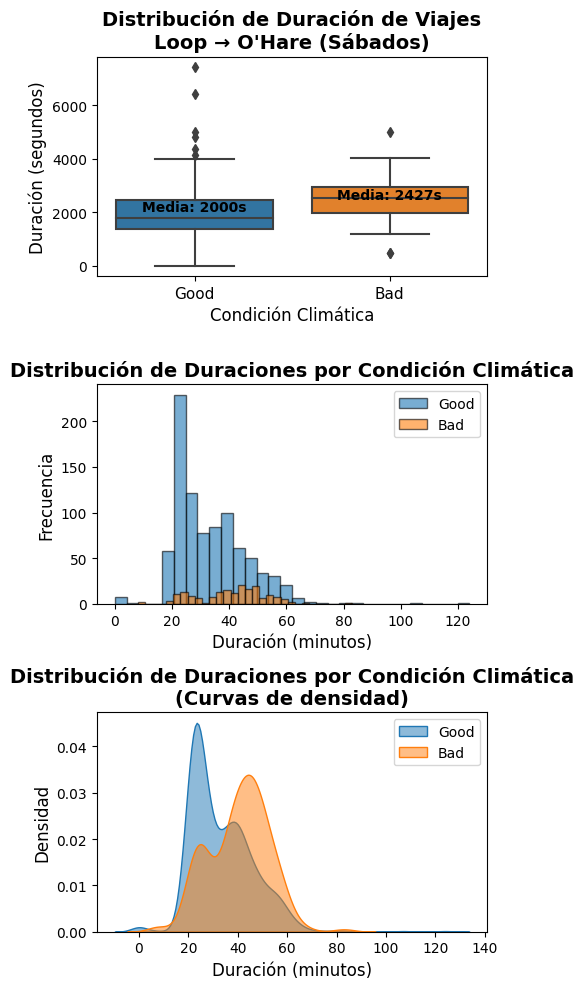

In [46]:
#Visualización de datos

fig, axess = plt.subplots(3, 1, figsize=(5, 10))

# Gráfico 1: Boxplot de duraciones por condición climática
sns.boxplot(data=df_weather, x='weather_conditions', y='duration_seconds', ax=axess[0], palette=['#1f77b4', '#ff7f0e'])
axess[0].set_title('Distribución de Duración de Viajes\nLoop → O\'Hare (Sábados)', fontsize=14, fontweight='bold')
axess[0].set_xlabel('Condición Climática', fontsize=12)
axess[0].set_ylabel('Duración (segundos)', fontsize=12)
axess[0].tick_params(axis='x', labelsize=11)

# Añadir anotaciones con la media
means = df_weather.groupby('weather_conditions')['duration_seconds'].mean()
for i, condition in enumerate(['Good', 'Bad']):
    axess[0].text(i, means[condition] + 50, f'Media: {means[condition]:.0f}s', 
                 ha='center', fontsize=10, fontweight='bold')

# Gráfico 2: Histogramas
for condition in df_weather['weather_conditions'].unique():
    subset = df_weather[df_weather['weather_conditions'] == condition]
    axess[1].hist(subset['duration_seconds']/60, bins=30, alpha=0.6, label=f'{condition}', edgecolor='black')
axess[1].set_xlabel('Duración (minutos)', fontsize=12)
axess[1].set_ylabel('Frecuencia', fontsize=12)
axess[1].set_title('Distribución de Duraciones por Condición Climática', fontsize=14, fontweight='bold')
axess[1].legend()

#Gráfico 3: Proporciones
for condition in df_weather['weather_conditions'].unique():
    subset = df_weather[df_weather['weather_conditions'] == condition]['duration_seconds'] / 60
    sns.kdeplot(subset, ax=axess[2], label=f'{condition}', shade=True, alpha=0.5)

axess[2].set_xlabel('Duración (minutos)', fontsize=12)
axess[2].set_ylabel('Densidad', fontsize=12)
axess[2].set_title('Distribución de Duraciones por Condición Climática\n(Curvas de densidad)', fontsize=14, fontweight='bold')
axess[2].legend()

plt.tight_layout()
plt.show()

In [47]:
# Prueba de normalidad

print("\n" + "=" * 60)
print("PRUEBA DE NORMALIDAD (Shapiro-Wilk)")
print("=" * 60)

from scipy.stats import shapiro

for condition in df_weather['weather_conditions'].unique():
    subset = df_weather[df_weather['weather_conditions'] == condition]['duration_seconds']
    statistic, p_value = shapiro(subset)
    print(f"\n📌 Condición: {condition}")
    print(f"   Estadístico: {statistic:.4f}")
    print(f"   p-valor: {p_value:.6f}")
    if p_value > 0.05:
        print("   → Los datos siguen una distribución NORMAL (no se rechaza H₀)")
    else:
        print("   → Los datos NO siguen una distribución NORMAL (se rechaza H₀)")


PRUEBA DE NORMALIDAD (Shapiro-Wilk)

📌 Condición: Good
   Estadístico: 0.9096
   p-valor: 0.000000
   → Los datos NO siguen una distribución NORMAL (se rechaza H₀)

📌 Condición: Bad
   Estadístico: 0.9762
   p-valor: 0.003612
   → Los datos NO siguen una distribución NORMAL (se rechaza H₀)


#### Formulación de hipotesis

**Hipótesis Nula (H₀):** No hay diferencias en la duración promedio de los viajes en día sábado con clima "Bad" (Malo) o con clima "Good" (Buneo). x̅ Bad ≠ x̅ Good.

**Hipótesis Altenativa (H₁):** Existe una diferencia en la duración promedio de los viajes en día sábado con clima "Bad" (Malo) o con clima "Good" (Buneo). x̅ Bad = x̅ Good.

**Nivel de significación (α):** 0.05 (5%)

Se usara la prueba Mann-Withney U ya que nuestros datos no siguen una distribución normal.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo formulando la hipótesis! Es fundamental que sea claro lo que se busca analizar.

</div>

In [54]:
bad_weather = df_weather[df_weather['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_weather[df_weather['weather_conditions'] == 'Good']['duration_seconds']

print(f"\n 📊 Resumen de datos:")
print(f"Clima 'Bad' (Lluvia/tormenta): n={len(bad_weather):.2f}, \n  media={bad_weather.mean():.2f}")
print(f"Clima 'Good': n={len(good_weather):.2f}, \n  media={good_weather.mean():.2f}")
print("Diferencia entre medias:", bad_weather.mean()-good_weather.mean(), "segundos o", (bad_weather.mean()-good_weather.mean())/60, "minutos")


 📊 Resumen de datos:
Clima 'Bad' (Lluvia/tormenta): n=180.00, 
  media=2427.21
Clima 'Good': n=888.00, 
  media=1999.68
Diferencia entre medias: 427.5298798798801 segundos o 7.125497997998002 minutos


In [50]:
# Prueba Mann-Whitney U
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(bad_weather, good_weather, alternative='two-sided')

print(f"\n📈 Resultados de la prueba de Mann-Whitney U:")
print(f"   Estadístico U: {statistic:.2f}")
print(f"   p-valor: {p_value:.6f}")
print(f"   Nivel de significación (α): 0.05")


📈 Resultados de la prueba de Mann-Whitney U:
   Estadístico U: 108193.50
   p-valor: 0.000000
   Nivel de significación (α): 0.05


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Interpretaste correctamente el valor p y sacaste conclusiones estadísticas válidas. Debemos rechazar efectivamente la hipótesis nula. 

</div>

### Conclusión general

Obtuvimos p-valor (≈ 0) < α (0.05) por lo tanto **Rechazamos Hipótesis Nula (H₀)**, Existe evidencia estadisticaménte significativa de que la duración promedio de los viajes desde Loop hasta O'Hare es DIFERENTE entre los días sábado con clima "Bad" en comparación con sábados con clima good (40min > 33min) con una diferencia de 7 minutos. Es decir que los viajes en días lloviosos son más largos.

1. Los sábados con mal clima (lluvia/tormenta) muestran diferencias en
   la duración de los viajes hacia el aeropuerto.

2. Recomendación: Implementar precios dinámicos que consideren:
   - Condiciones climáticas adversas
   - Mayor demanda potencial en días lluviosos

3. Estrategia de flota: Aumentar disponibilidad de vehículos en
   días de lluvia para reducir tiempos de espera.

4. Comunicación con usuarios: Notificar sobre posibles demoras
   en días de lluvia y ofrecer rutas alternativas.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Dejas durante todo el proyecto comentarios correctos y conclusiones super claras.

</div>